##Week3
**로지스틱 회귀 모델을 위한 데이터 만들기**

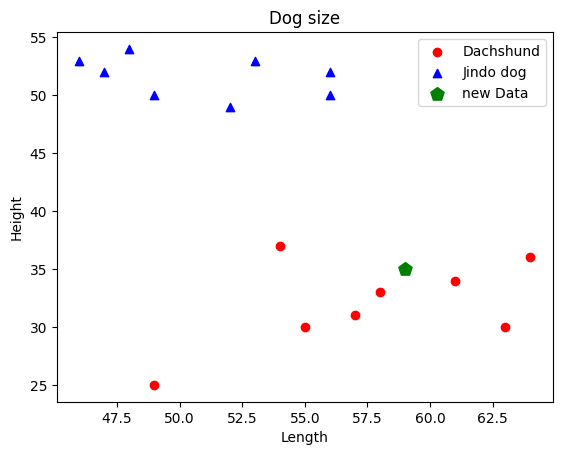

In [3]:
import matplotlib.pyplot as plt

# 닥스훈트의 길이와 높이 데이터
dach_length = [55, 57, 64, 63, 58, 49, 54, 61]
dach_height = [30, 31, 36, 30, 33, 25, 37, 34]
# 진돗개의 길이와 높이 데이터
jin_length = [56, 47, 56, 46, 49, 53, 52, 48]
jin_height = [52, 52, 50, 53, 50, 53, 49, 54]

newdata_length = [59]    # 새로운 데이터의 길이
newdata_height = [35]    # 새로운 데이터의 높이

plt.scatter(dach_length, dach_height, c='r', label='Dachshund')
plt.scatter(jin_length, jin_height,c='b',marker='^', label='Jindo dog')
# 새 데이터의 표식은 오각형(pentagon)으로 설정하고, 레이블은 new Data로
plt.scatter(newdata_length, newdata_height, s=100, marker='p',\
           c='g', label='new Data')

plt.xlabel('Length')
plt.ylabel('Height')
plt.title("Dog size")
plt.legend(loc='upper right')

In [4]:
import numpy as np

d_data = np.column_stack((dach_length, dach_height))
d_label = np.zeros(len(d_data))   # 닥스훈트는 0으로 레이블링
# len(d_data)는 d_data 배열의 첫 번째 차원(행의 개수)의 길이를 반환

j_data = np.column_stack((jin_length, jin_height))
j_label = np.ones(len(j_data))   # 진돗개는 1로 레이블링

d_data, d_label, j_data, j_label

(array([[55, 30],
        [57, 31],
        [64, 36],
        [63, 30],
        [58, 33],
        [49, 25],
        [54, 37],
        [61, 34]]),
 array([0., 0., 0., 0., 0., 0., 0., 0.]),
 array([[56, 52],
        [47, 52],
        [56, 50],
        [46, 53],
        [49, 50],
        [53, 53],
        [52, 49],
        [48, 54]]),
 array([1., 1., 1., 1., 1., 1., 1., 1.]))

**로지스틱 회귀 모델 구현하기**

In [5]:
import numpy as np

newdata = [[59, 35]]
dogs = np.concatenate((d_data, j_data))
labels = np.concatenate((d_label, j_label))
dog_classes = {0:'닥스훈트', 1:'진돗개'} # 이 코드는 숫자 레이블(0과 1)에 해당하는 견종 이름을 매핑하는 딕셔너리

In [6]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn import metrics # metrics 모듈은 모델의 성능 평가하는 다양한 지표 제공

f = LogisticRegression()
f.fit(dogs, labels) # 모델을 학습시키는 함수(fit)
# fit 메서드는 dogs (특징 데이터, 즉 개의 길이와 높이)와 labels (정답 레이블, 0 또는 1)를 사용하여 모델이 데이터의 패턴을 학습하도록 함

w = f.coef_[0] # 학습 모델의 계수
b = f.intercept_[0] # 학습 모델의 절편
print('계수:', w)
print('절편:', b)
print('분류 정확도:', f.score(dogs, labels))
# score 메서드는 학습에 사용된 dogs 데이터와 labels를 다시 사용하여 모델이 얼마나 잘 분류하는지 비율로 나타냄

y_pred = f.predict(newdata) # predict 함수는 배열 형태로 리턴
# predict 메서드는 새로운 데이터에 대한 예측 레이블을 얻는 함수

y_pred_prob = f.predict_proba(newdata)  #predict_proba 함수는 배열 형태로 리턴
print(f'데이터: {newdata}')
print(f'판정 결과: {dog_classes[y_pred[0]]}, 판정 확률: {y_pred_prob}')

계수: [-0.12467735  0.60518946]
절편: -19.029836138332463
분류 정확도: 1.0
데이터: [[59, 35]]
판정 결과: 닥스훈트, 판정 확률: [[0.9945364 0.0054636]]


**결정 경계 확인하기**

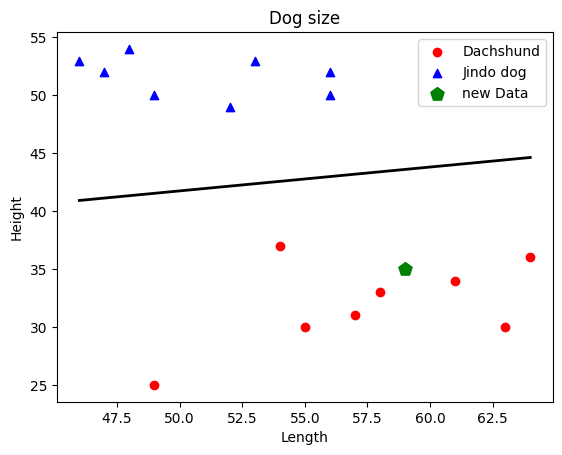

In [7]:
plt.scatter(dach_length, dach_height, c='r', label='Dachshund')
plt.scatter(jin_length, jin_height,c='b',marker='^', label='Jindo dog')
# 새 데이터의 표식은 오각형(pentagon)으로 설정하고, 레이블은 new Data로
plt.scatter(newdata_length, newdata_height, s=100, marker='p',\
           c='g', label='new Data')

plt.xlabel('Length')
plt.ylabel('Height')
plt.title("Dog size")
plt.legend(loc='upper right')

x0 = np.linspace(np.min([dach_length, jin_length]),\
                 np.max([dach_length, jin_length]), 200)
decision_boundary = -w[0]/w[1] * x0 - b/w[1]
# 결정 경계에서 w0*x0 + w1*x1 + b = 0 이므로 => x1 = -w0/w1 * x0 - b/w1
plt.plot(x0, decision_boundary, "k-", linewidth=2)

**결정 경계 확인하기(2)**

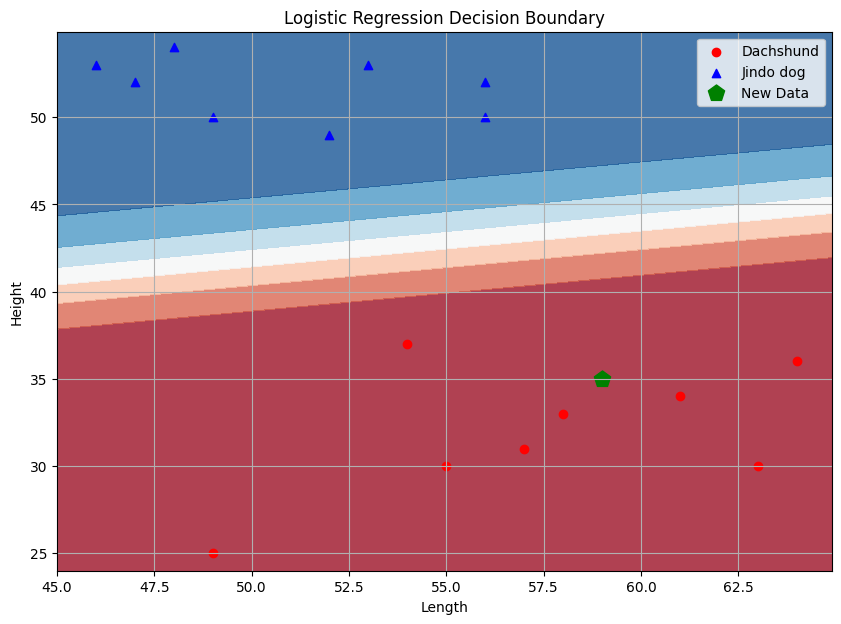

In [8]:
import matplotlib.pyplot as plt

# --- 1. 그래프의 범위 설정 --- #
# 닥스훈트와 진돗개 데이터(길이 x축, 높이 y축)의 최소/최대 값 기준
x_min, x_max = dogs[:, 0].min() - 1, dogs[:, 0].max() + 1
y_min, y_max = dogs[:, 1].min() - 1, dogs[:, 1].max() + 1

# --- 2. 결정 경계 시각화를 위한 가상 격자(메시그리드) 생성 --- #
# 그래프 전체 영역을 0.1 단위의 작은 격자로 나눔
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# --- 3. 가상 격자 점들에 대해 모델 예측 수행 및 결과 준비 --- #
Z = f.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 7))

# --- 4. 결정 경계 및 데이터 포인트 시각화 --- #
# 4-1. 결정 경계 플롯 (색상으로 영역 구분)
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdBu)

# 4-2. 실제 데이터 포인트 플롯
plt.scatter(dach_length, dach_height, c='r', marker='o', label='Dachshund')
plt.scatter(jin_length, jin_height, c='b', marker='^', label='Jindo dog')

# 4-3. 새로운 데이터 포인트 플롯
newdata_length = [59]
newdata_height = [35]
plt.scatter(newdata_length, newdata_height, s=150, marker='p', c='g', label='New Data')

# --- 5. 그래프 최종 설정 --- #
plt.xlabel('Length')
plt.ylabel('Height')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
dach_0 = w[0]*dach_length[0] + w[1]*dach_height[0] + b
jin_0 = w[0]*jin_length[0] + w[1]*jin_height[0] + b
print('닥스훈트 샘플 대입 결과:', dach_0)
print('진돗개 샘플 대입 결과:', jin_0)

닥스훈트 샘플 대입 결과: -7.731406281355827
진돗개 샘플 대입 결과: 5.458084542961522
